# Email marketing campaign

In this article, I analyze how successful an email marketing campaign was. The source database and useful questions were provided by [Mary Knoeferl](https://www.linkedin.com/in/mary-knoeferl/).

## Introduction

The purpose of this exercise is to analyze an email marketing campaign and to emulate doing SQL queries to a database for demonstration purposes only. Manipulating such a small database is easier by importing its content to dataframes and transforming the data using Python.

## Understanding the tables

First, I'll read the database using SQLite and Python to access the data. Then I´ll do some basic queries to understand the database structure and its content.

In [ ]:
# Import libraries :)
import sqlite3
import pandas as pd

# Connect to the .db file
conn = sqlite3.connect('email_marketing.db')  


I don't know the content of the file nor anything about the database, so I'll first understand which tables belong to the database.

In [ ]:
query_tables = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql_query(query_tables, conn)
print("Found tables:")
print(tables)



Found tables:
                   name
0                 Users
1             Campaigns
2      Email_Engagement
3  Campaign_Performance
4          Unsubscribes


Luckily, it's a small database. I'll read the first lines of table **Users** to see its attributes.

In [ ]:
nombre_tabla = 'Users'
df = pd.read_sql_query(f"SELECT * FROM {nombre_tabla} LIMIT 5;", conn)
print(f"First 5 entries from table '{nombre_tabla}':")
print(df)

First 5 entries from table 'Users':
   user_id signup_date device_type         region  is_active
0        1  2023-10-01     desktop  South America          0
1        2  2023-09-07      mobile         Europe          0
2        3  2023-06-12     desktop         Europe          0
3        4  2024-02-27     desktop           Asia          0
4        5  2024-06-13     desktop         Europe          1


I'll repeat the same commands for the rest of the tables.

In [ ]:
names = tables['name'].tolist()
for nombre_tabla in names:
    df = pd.read_sql_query(f"SELECT * FROM {nombre_tabla} LIMIT 15;", conn)
    print(f"\nFirst 15 entries from table '{nombre_tabla}':")
    print(df)


First 15 entries from table 'Users':
    user_id signup_date device_type         region  is_active
0         1  2023-10-01     desktop  South America          0
1         2  2023-09-07      mobile         Europe          0
2         3  2023-06-12     desktop         Europe          0
3         4  2024-02-27     desktop           Asia          0
4         5  2024-06-13     desktop         Europe          1
5         6  2024-03-07     desktop  South America          1
6         7  2023-02-15      mobile           Asia          1
7         8  2023-10-26      tablet           Asia          1
8         9  2023-03-27     desktop           Asia          1
9        10  2024-02-06      tablet         Europe          0
10       11  2024-08-10     desktop         Europe          0
11       12  2024-05-05     desktop  North America          0
12       13  2023-08-28      tablet           Asia          1
13       14  2024-07-19      tablet         Europe          1
14       15  2023-12-30      tab

I want to know the data types of the tables:

In [ ]:
for nombre_tabla in names:
     estructura = pd.read_sql_query(f"PRAGMA table_info({nombre_tabla});", conn)
     print(f"Estructura de la tabla '{nombre_tabla}':")
     print(estructura)


Estructura de la tabla 'Users':
   cid         name     type  notnull dflt_value  pk
0    0      user_id  INTEGER        0       None   1
1    1  signup_date     DATE        0       None   0
2    2  device_type     TEXT        0       None   0
3    3       region     TEXT        0       None   0
4    4    is_active  BOOLEAN        0       None   0
Estructura de la tabla 'Campaigns':
   cid           name     type  notnull dflt_value  pk
0    0    campaign_id  INTEGER        0       None   1
1    1  campaign_name     TEXT        0       None   0
2    2      send_date     DATE        0       None   0
3    3  email_subject     TEXT        0       None   0
4    4      send_hour  INTEGER        0       None   0
5    5       category     TEXT        0       None   0
Estructura de la tabla 'Email_Engagement':
   cid           name      type  notnull dflt_value  pk
0    0  engagement_id   INTEGER        0       None   1
1    1        user_id   INTEGER        0       None   0
2    2    campaign

Let's see the size of the tables:

In [ ]:
for nombre_tabla in names:
    count_query = f"SELECT COUNT(*) FROM {nombre_tabla};"
    count_result = pd.read_sql_query(count_query, conn)
    print(f"Number of records in table '{nombre_tabla}': {count_result.iloc[0, 0]}")

Number of records in table 'Users': 5000
Number of records in table 'Campaigns': 20
Number of records in table 'Email_Engagement': 30000
Number of records in table 'Campaign_Performance': 20
Number of records in table 'Unsubscribes': 1516


Count total unsubscribes from table **Unsubscribes**:

In [ ]:
#SELECT COUNT(DISTINCT userid) AS distinct_unsubscribers
#FROM unsubscribes;
#SELECT userid, COUNT(campaignid) AS total_unsubscribes
#FROM Unsubscribes
#GROUP BY userid
unsubscribes_query = f"SELECT user_id, COUNT(campaign_id) AS total_unsubscribes FROM Unsubscribes GROUP BY user_id;"
unsubscribes_result = pd.read_sql_query(unsubscribes_query, conn)
print(unsubscribes_result)

      user_id  total_unsubscribes
0           7                   1
1          10                   1
2          21                   1
3          32                   1
4          37                   1
...       ...                 ...
1291     4989                   1
1292     4992                   1
1293     4995                   1
1294     4996                   2
1295     4998                   1

[1296 rows x 2 columns]


Number of unsubscribes


In [ ]:
#GROUP BY userid
unsubscribes_query = f"SELECT COUNT(user_id) FROM Unsubscribes;"
unsubscribes_result = pd.read_sql_query(unsubscribes_query, conn)
print(unsubscribes_result)

   COUNT(user_id)
0            1516


Number of sent, opened, clicked emails and unsubscribes. There is a comparatively small number of emails that were probably not opened, but are stored in a variable named `unknown`.

In [ ]:
unsubscribes_query = f"""
SELECT SUM(total_sent) AS sent,SUM(total_opens) AS opens, SUM(total_clicks) AS clicks, 
       SUM(total_unsubscribes) AS unsubscribes 
FROM Campaign_Performance;"""
unsubscribes_result = pd.read_sql_query(unsubscribes_query, conn)
print(unsubscribes_result)

sent = unsubscribes_result.iloc[0, 0]
opens = unsubscribes_result.iloc[0, 1]  
clicks = unsubscribes_result.iloc[0, 2]  
unsubscribes = unsubscribes_result.iloc[0, 3]
unknown = sent - (opens + clicks + unsubscribes)



    sent  opens  clicks  unsubscribes
0  30000  17916    5421          1516


Let's see which percentage corresponds to each category:

In [ ]:
p_opens = opens/sent
p_clicks = clicks/sent
p_unsubscribes = unsubscribes/sent
p_not_opened = 1-(opens/sent)
print(f"% opens: {p_opens*100}, % clicks: {p_clicks*100}, % unsubscribes: {p_unsubscribes*100}, % not read: {p_not_opened*100}")

% opens: 59.72, % clicks: 18.07, % unsubscribes: 5.053333333333334, % not read: 40.28


59.72% of emails were opened, 18.07% resulted in clicks, 5.05% led to unsubscribes, and 40% were not opened. 
I'd assume that only the opened emails could lead to clicks and unsubscribes. Let's analyze which campaign got more unsubscribes. Table **Campaigns** shows the campaigns to analyze.

In [ ]:
campaigns_query = f"SELECT * FROM Campaigns;"
campaigns_result = pd.read_sql_query(campaigns_query, conn)
print(campaigns_result)

    campaign_id campaign_name   send_date    email_subject  send_hour  \
0             1    Campaign 1  2024-07-22   Subject line 1         18   
1             2    Campaign 2  2024-08-28   Subject line 2          9   
2             3    Campaign 3  2024-02-20   Subject line 3         18   
3             4    Campaign 4  2024-02-26   Subject line 4         13   
4             5    Campaign 5  2024-06-02   Subject line 5         20   
5             6    Campaign 6  2024-02-14   Subject line 6          8   
6             7    Campaign 7  2024-05-31   Subject line 7         10   
7             8    Campaign 8  2024-06-26   Subject line 8         12   
8             9    Campaign 9  2024-08-24   Subject line 9          9   
9            10   Campaign 10  2024-06-08  Subject line 10         14   
10           11   Campaign 11  2024-03-31  Subject line 11          7   
11           12   Campaign 12  2024-09-24  Subject line 12         13   
12           13   Campaign 13  2024-08-26  Subject 

Table **Campaign_Performance** has the number of unsubscribes by campaign.

In [ ]:
campaigns_query = f"""
SELECT * FROM Campaign_Performance 
ORDER BY total_unsubscribes DESC;"""
campaigns_result = pd.read_sql_query(campaigns_query, conn)
print(campaigns_result)

    campaign_id  total_sent  total_opens  total_clicks  total_unsubscribes
0             2        1500          881           273                  88
1             1        1500          885           260                  87
2             8        1500          898           244                  86
3            14        1500          899           285                  86
4            18        1500          896           260                  82
5             6        1500          895           257                  81
6            15        1500          900           276                  81
7             3        1500          875           288                  80
8             4        1500          882           261                  78
9            16        1500          910           311                  76
10           17        1500          890           254                  76
11           10        1500          901           287                  75
12            9        15

However, the purpose of this notebook is to try some SQL queries. I'll query tables **Campaigns** and **Unsubscribes** to obtain the same information. First I'll list campaigns and will group them by reason and number of unsubscribes.

In [ ]:
unsubscribes_query = f"""
SELECT 
    u.campaign_id,
    campaign_name,
    category,
    reason,
    COUNT(*) AS unsubscribe_count
FROM Unsubscribes u JOIN Campaigns c 
ON u.campaign_id = c.campaign_id
GROUP BY u.campaign_id, reason
ORDER BY u.campaign_id, unsubscribe_count DESC;
"""
unsubscribes_result = pd.read_sql_query(unsubscribes_query, conn)
print(unsubscribes_result)

    campaign_id campaign_name   category              reason  \
0             1    Campaign 1  promotion               Other   
1             1    Campaign 1  promotion    Privacy concerns   
2             1    Campaign 1  promotion  Found better brand   
3             1    Campaign 1  promotion        Not relevant   
4             1    Campaign 1  promotion     Too many emails   
..          ...           ...        ...                 ...   
95           20   Campaign 20  promotion        Not relevant   
96           20   Campaign 20  promotion     Too many emails   
97           20   Campaign 20  promotion    Privacy concerns   
98           20   Campaign 20  promotion  Found better brand   
99           20   Campaign 20  promotion               Other   

    unsubscribe_count  
0                  23  
1                  20  
2                  20  
3                  18  
4                   6  
..                ...  
95                 19  
96                 17  
97             

Then I'll compact that query by not taking **reason** into account.

In [ ]:
unsubscribes_query = f"""
SELECT 
    u.campaign_id,
    campaign_name,
    COUNT(*) AS unsubscribe_count
FROM Unsubscribes u JOIN Campaigns c 
ON u.campaign_id = c.campaign_id
GROUP BY u.campaign_id
ORDER BY unsubscribe_count DESC;
"""
unsubscribes_result = pd.read_sql_query(unsubscribes_query, conn)
print(unsubscribes_result)

    campaign_id campaign_name  unsubscribe_count
0             2    Campaign 2                 88
1             1    Campaign 1                 87
2            14   Campaign 14                 86
3             8    Campaign 8                 86
4            18   Campaign 18                 82
5            15   Campaign 15                 81
6             6    Campaign 6                 81
7             3    Campaign 3                 80
8             4    Campaign 4                 78
9            17   Campaign 17                 76
10           16   Campaign 16                 76
11           10   Campaign 10                 75
12           20   Campaign 20                 74
13            9    Campaign 9                 74
14           19   Campaign 19                 72
15            7    Campaign 7                 72
16            5    Campaign 5                 71
17           12   Campaign 12                 64
18           11   Campaign 11                 62
19           13   Ca

Although very probably this database is made up of synthetic data, the query yielded the same results as table **Campaign_Performance**, which is good!

Now I want to know which campaigns got more unsubscribes. The query shows from the most unsuccessful campaigns to the most successful campaigns.

In [ ]:
campaigns_query = f"""
SELECT * FROM Campaign_Performance 
GROUP BY campaign_id
ORDER BY total_unsubscribes DESC;"""
campaigns_result = pd.read_sql_query(campaigns_query, conn)
print(campaigns_result)

    campaign_id  total_sent  total_opens  total_clicks  total_unsubscribes
0             2        1500          881           273                  88
1             1        1500          885           260                  87
2             8        1500          898           244                  86
3            14        1500          899           285                  86
4            18        1500          896           260                  82
5             6        1500          895           257                  81
6            15        1500          900           276                  81
7             3        1500          875           288                  80
8             4        1500          882           261                  78
9            16        1500          910           311                  76
10           17        1500          890           254                  76
11           10        1500          901           287                  75
12            9        15



Now for what caused more engagement. The following query shows the campaigns that got more clicks.

In [ ]:
campaigns_query = f"""
SELECT * FROM Campaign_Performance 
GROUP BY campaign_id
ORDER BY total_clicks DESC;"""
campaigns_result = pd.read_sql_query(campaigns_query, conn)
print(campaigns_result)

    campaign_id  total_sent  total_opens  total_clicks  total_unsubscribes
0            16        1500          910           311                  76
1             3        1500          875           288                  80
2            10        1500          901           287                  75
3            14        1500          899           285                  86
4            11        1500          938           283                  62
5            12        1500          915           282                  64
6            20        1500          879           278                  74
7            15        1500          900           276                  81
8             2        1500          881           273                  88
9            13        1500          892           273                  51
10           19        1500          895           273                  72
11            9        1500          903           266                  74
12            4        15

Campaign 14 is interesting because it succeeded in number of clicks but also got many unsubscribes. Next Let's count the number of emails opened and compare it to the number of emails not opened.

In [ ]:

nombre_tabla = "Email_Engagement"
total = pd.read_sql_query(f"SELECT COUNT(*) FROM {nombre_tabla};", conn)
print(total)
opened = pd.read_sql_query(f"SELECT COUNT(opened) FROM {nombre_tabla} WHERE opened = 1;", conn)
print(df)

ratio = opened.iloc[0, 0] / total.iloc[0, 0]
print(f"Open Rate: {ratio:.2%}")

   COUNT(*)
0     30000
    unsubscribe_id  user_id  campaign_id unsubscribe_date              reason
0                1     3231            1       2024-02-09  Found better brand
1                2     3533            1       2024-01-16    Privacy concerns
2                3      818            1       2024-04-27  Found better brand
3                4     2176            1       2024-01-01    Privacy concerns
4                5     3023            1       2024-09-03               Other
5                6      572            1       2024-04-17    Privacy concerns
6                7     4032            1       2024-09-28    Privacy concerns
7                8     4400            1       2024-03-22               Other
8                9     3524            1       2024-01-01  Found better brand
9               10      788            1       2024-01-01        Not relevant
10              11     2464            1       2024-09-13    Privacy concerns
11              12     1712            1

## Graph example

The following graph shows the unsubscribe trends per month. First I need to transform the data.

In [ ]:
month_unsubscribes_query = f"""
SELECT COUNT(*) AS total_unsubscribes, strftime('%Y-%m', unsubscribe_date) AS month
FROM Unsubscribes
GROUP BY strftime('%Y-%m', unsubscribe_date)
ORDER BY month;"""
month_unsubscribes_result = pd.read_sql_query(month_unsubscribes_query, conn)
print(month_unsubscribes_result)


   total_unsubscribes    month
0                 713  2024-01
1                 110  2024-02
2                 106  2024-03
3                  88  2024-04
4                 109  2024-05
5                  84  2024-06
6                 109  2024-07
7                  97  2024-08
8                 100  2024-09


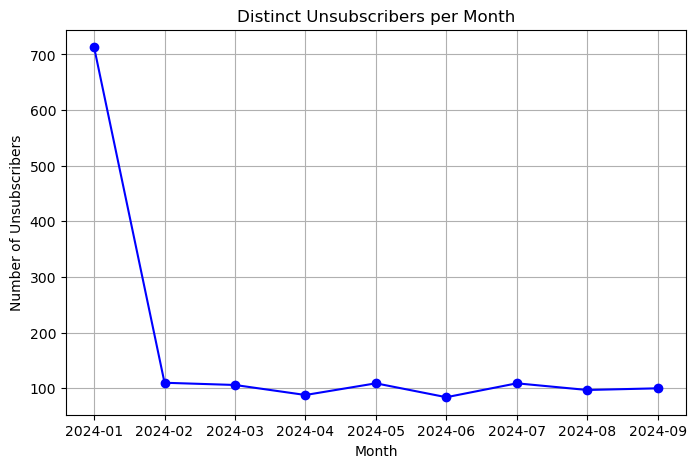

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


# Create line chart
plt.figure(figsize=(8,5))
plt.plot(month_unsubscribes_result['month'], month_unsubscribes_result['total_unsubscribes'], marker='o', linestyle='-', color='blue')

# Add labels and title
plt.title('Distinct Unsubscribers per Month')
plt.xlabel('Month')
plt.ylabel('Number of Unsubscribers')

# Show grid for readability
plt.grid(True)

# Display chart
plt.show()

In [ ]:
conn.close()

## Conclusion

The number of clicks surpassed the number of unsubscribes, so the data suggests that overall, the email campaign performance is really good. It would be worthwhile to analyze **Campaign 14** because it was in the top 5 best performing campaigns but it also was among the campaigns that led to more unsubscribes. 

The recommendation is to keep the best performing campaigns, that is, the ones that had more clicks.